# GNN Aggregation and Regularization Analysis on Cora
This notebook investigates how different aggregation functions (Mean vs. Max) affect the expressibility and overfitting of a GNN on the Cora dataset.

In [3]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.3 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, SAGEConv
import matplotlib.pyplot as plt

# Load Cora dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]
print(f'Dataset: {dataset}:')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Processing...


Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7


Done!


In [5]:
import torch

# Calculate node degrees
degrees = torch.bincount(data.edge_index[0], minlength=data.num_nodes)

# Find min and max degrees
min_degree = torch.min(degrees).item()
max_degree = torch.max(degrees).item()

print(f'Minimum node degree: {min_degree}')
print(f'Maximum node degree: {max_degree}')
print(f'Total number of edges: {len(data.edge_index[0])}')
print(f'Total number of nodes: {len(degrees)}')



Minimum node degree: 1
Maximum node degree: 168
Total number of edges: 10556
Total number of nodes: 2708


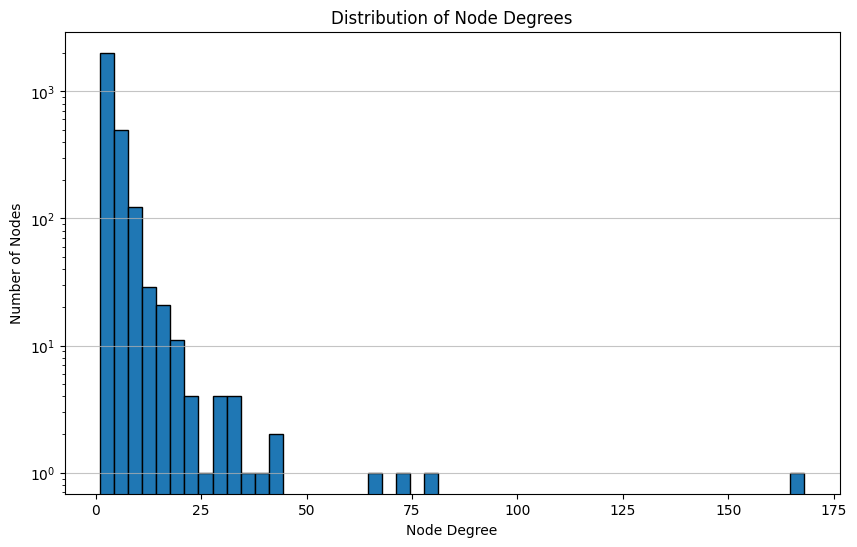

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(degrees.cpu().numpy(), bins=50, edgecolor='black')
plt.title('Distribution of Node Degrees')
plt.xlabel('Node Degree')
plt.ylabel('Number of Nodes')
plt.grid(axis='y', alpha=0.75)
plt.yscale('log')
plt.show()

In [7]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels, aggr='mean'):
        super().__init__()
        # Using GraphSAGE as it explicitly supports different aggregation types
        self.conv1 = SAGEConv(dataset.num_features, hidden_channels, aggr=aggr)
        self.conv2 = SAGEConv(hidden_channels, dataset.num_classes, aggr=aggr)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        #x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [6]:
def train_and_evaluate(aggr_type, epochs=200):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GNN(hidden_channels=16, aggr=aggr_type).to(device)
    data_to_device = data.to(device)
    # No weight decay, as we want to test regularizing power of AGGR func
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0)

    history = {'train_acc': [], 'test_acc': [], 'train_loss': []}

    for epoch in range(epochs):
        if epoch % 10 == 0:
            print(f'Epoch: {epoch}')
        model.train()
        optimizer.zero_grad()
        out = model(data_to_device.x, data_to_device.edge_index)
        loss = F.cross_entropy(out[data_to_device.train_mask], data_to_device.y[data_to_device.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        logits = model(data_to_device.x, data_to_device.edge_index)
        prediction = logits.argmax(dim=1)

        train_acc = (prediction[data_to_device.train_mask] == data_to_device.y[data_to_device.train_mask]).sum().item() / data_to_device.train_mask.sum().item()
        test_acc = (prediction[data_to_device.test_mask] == data_to_device.y[data_to_device.test_mask]).sum().item() / data_to_device.test_mask.sum().item()

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['train_loss'].append(loss.item())

    return history

results_mean = train_and_evaluate('mean')
results_max = train_and_evaluate('max')
results_sum = train_and_evaluate('sum')

print("Training complete for both Mean, Sum and Max aggregation.")

Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 50
Epoch: 60
Epoch: 70
Epoch: 80
Epoch: 90
Epoch: 100
Epoch: 110
Epoch: 120
Epoch: 130
Epoch: 140
Epoch: 150
Epoch: 160
Epoch: 170
Epoch: 180
Epoch: 190
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 50
Epoch: 60
Epoch: 70
Epoch: 80
Epoch: 90
Epoch: 100
Epoch: 110
Epoch: 120
Epoch: 130
Epoch: 140
Epoch: 150
Epoch: 160
Epoch: 170
Epoch: 180
Epoch: 190
Epoch: 0
Epoch: 10
Epoch: 20
Epoch: 30
Epoch: 40
Epoch: 50
Epoch: 60
Epoch: 70
Epoch: 80
Epoch: 90
Epoch: 100
Epoch: 110
Epoch: 120
Epoch: 130
Epoch: 140
Epoch: 150
Epoch: 160
Epoch: 170
Epoch: 180
Epoch: 190
Training complete for both Mean, Sum and Max aggregation.


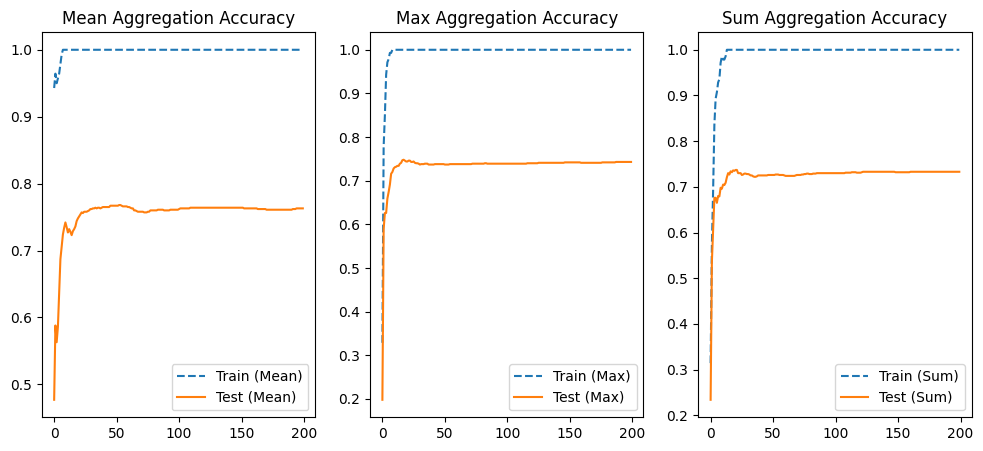

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(results_mean['train_acc'], label='Train (Mean)', linestyle='--')
plt.plot(results_mean['test_acc'], label='Test (Mean)')
plt.title('Mean Aggregation Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(results_max['train_acc'], label='Train (Max)', linestyle='--')
plt.plot(results_max['test_acc'], label='Test (Max)')
plt.title('Max Aggregation Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(results_sum['train_acc'], label='Train (Sum)', linestyle='--')
plt.plot(results_sum['test_acc'], label='Test (Sum)')
plt.title('Sum Aggregation Accuracy')
plt.legend()

plt.show()

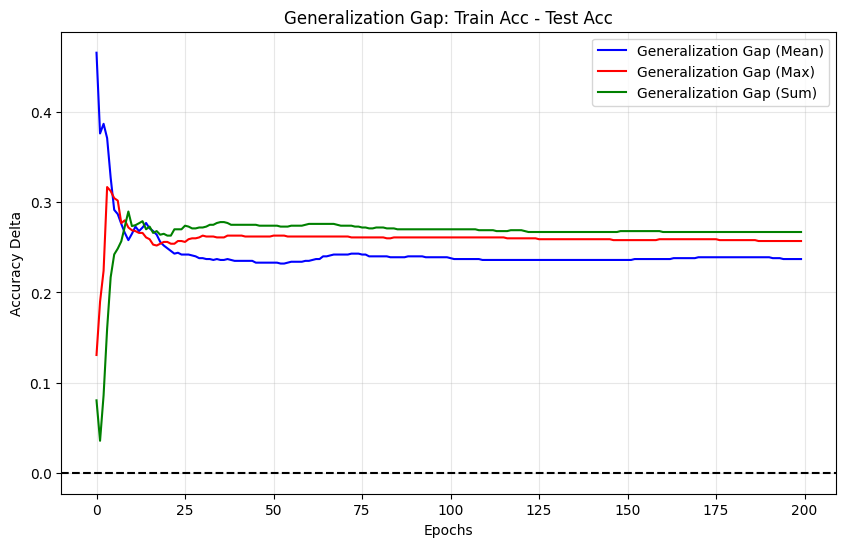

Final Gap (Mean): 0.2370
Final Gap (Max): 0.2570
Final Gap (Sum): 0.2670


In [8]:
import numpy as np

# Calculate deltas (Train Accuracy - Test Accuracy)
delta_mean = np.array(results_mean['train_acc']) - np.array(results_mean['test_acc'])
delta_max = np.array(results_max['train_acc']) - np.array(results_max['test_acc'])
delta_sum = np.array(results_sum['train_acc']) - np.array(results_sum['test_acc'])

# Plotting

plt.figure(figsize=(10, 6))
plt.plot(delta_mean, label='Generalization Gap (Mean)', color='blue')
plt.plot(delta_max, label='Generalization Gap (Max)', color='red')
plt.plot(delta_sum, label='Generalization Gap (Sum)', color='green')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Generalization Gap: Train Acc - Test Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Delta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Gap (Mean): {delta_mean[-1]:.4f}")
print(f"Final Gap (Max): {delta_max[-1]:.4f}")
print(f"Final Gap (Sum): {delta_sum[-1]:.4f}")

200 200 200


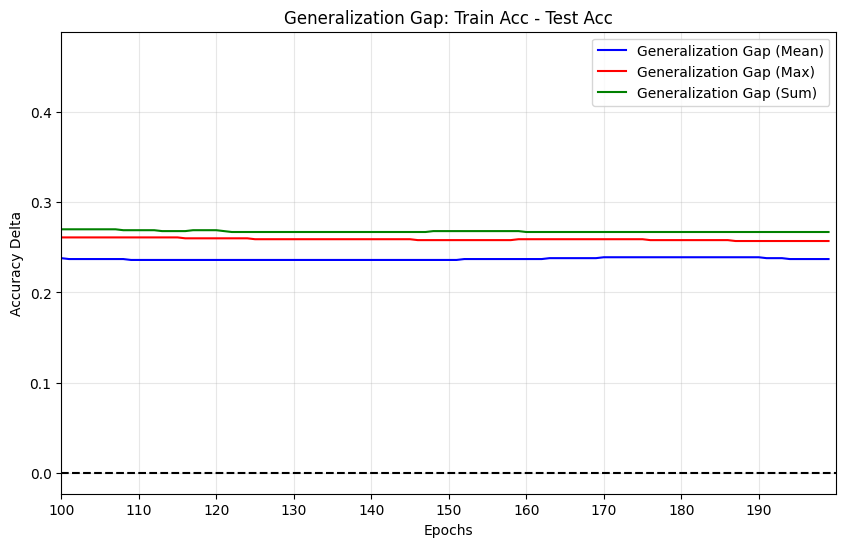

Final Gap (Mean): 0.2370
Final Gap (Max): 0.2570
Final Gap (Sum): 0.2670


In [9]:
import numpy as np

# Calculate deltas (Train Accuracy - Test Accuracy)
#delta_mean = delta_mean[100:]
#delta_max = delta_max[100:]
#delta_sum = delta_sum[100:]

print(len(delta_mean), len(delta_max), len(delta_sum))
# Plotting

plt.figure(figsize=(10, 6))
plt.plot(delta_mean, label='Generalization Gap (Mean)', color='blue')
plt.plot(delta_max, label='Generalization Gap (Max)', color='red')
plt.plot(delta_sum, label='Generalization Gap (Sum)', color='green')
plt.xlim(100, 200)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Generalization Gap: Train Acc - Test Acc')
plt.xlabel('Epochs')
plt.xticks(np.arange(100,200,step=10))
plt.ylabel('Accuracy Delta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Gap (Mean): {delta_mean[-1]:.4f}")
print(f"Final Gap (Max): {delta_max[-1]:.4f}")
print(f"Final Gap (Sum): {delta_sum[-1]:.4f}")

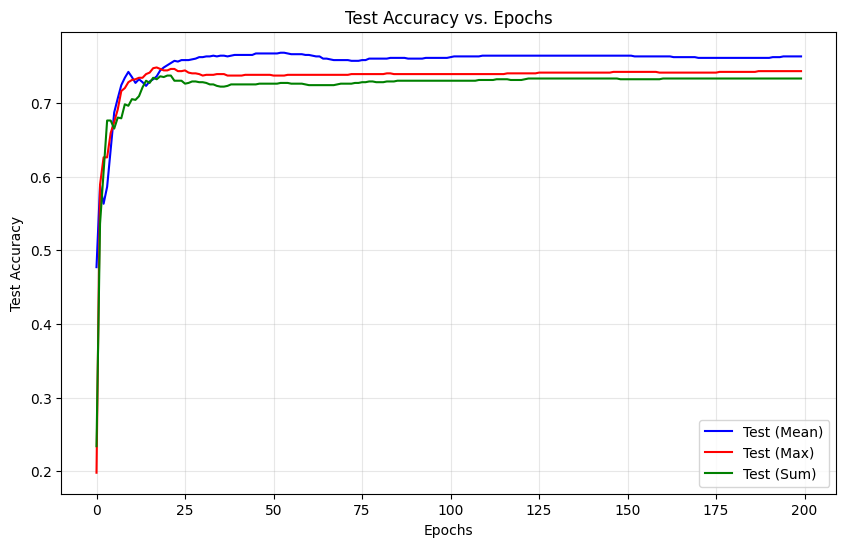

In [10]:
# plot test acc for each
plt.figure(figsize=(10, 6))
plt.plot(results_mean['test_acc'], label='Test (Mean)', color='blue')
plt.plot(results_max['test_acc'], label='Test (Max)', color='red')
plt.plot(results_sum['test_acc'], label='Test (Sum)', color='green')
plt.title('Test Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Adding noise to see if some aggregation function help with regularization
To see if Max or Mean aggregation 'filters' unimportant information better than Sum, we inject random noise edges into the dataset.

In [8]:
def add_noise(edge_index, noise_ratio=0.2, only_diff_label=True):
    num_nodes = data.num_nodes
    num_noise_edges = int(edge_index.size(1) * noise_ratio)

    new_edges = []
    while len(new_edges) < num_noise_edges:
        src = torch.randint(0, num_nodes, (1,)).item()
        dst = torch.randint(0, num_nodes, (1,)).item()
        if src == dst:
            continue
        if only_diff_label and data.y[src] == data.y[dst]:
            continue

        new_edges.append([src, dst])

    noise_edges = torch.tensor(new_edges, dtype=torch.long).t().to(edge_index.device)
    return torch.cat([edge_index, noise_edges], dim=1)

def test_robustness_v2(aggr_type, noise_levels):
    gaps = []
    for noise in noise_levels:
        noisy_edge_index = add_noise(data.edge_index, noise)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = GNN(hidden_channels=16, aggr=aggr_type).to(device)
        # again no weight decay to better test regularization
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0)

        for _ in range(200):
            model.train()
            optimizer.zero_grad()
            out = model(data.x.to(device), noisy_edge_index)
            loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask].to(device))
            loss.backward()
            optimizer.step()

        model.eval()
        logits = model(data.x.to(device), noisy_edge_index)
        prediction = logits.argmax(dim=1)
        train_acc = (prediction[data.train_mask] == data.y[data.train_mask].to(device)).sum().item() / data.train_mask.sum().item()
        test_acc = (prediction[data.test_mask] == data.y[data.test_mask].to(device)).sum().item() / data.test_mask.sum().item()
        gaps.append(train_acc - test_acc)
    return gaps

noise_levels = [0.0, 0.1, 0.3, 0.5]
robustness_mean_v2 = test_robustness_v2('mean', noise_levels)
robustness_max_v2 = test_robustness_v2('max', noise_levels)
robustness_sum_v2 = test_robustness_v2('sum', noise_levels)

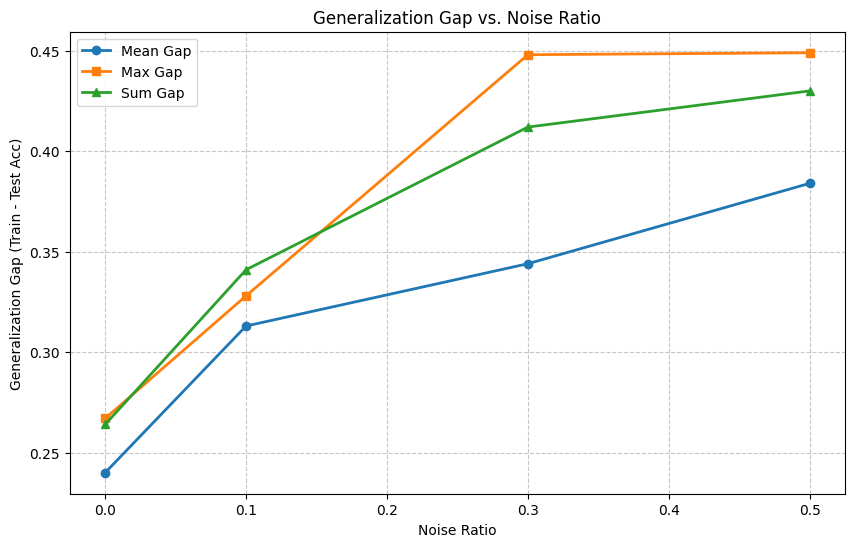

Noise 0% -> Gaps: Mean=0.240, Max=0.267, Sum=0.264
Noise 10% -> Gaps: Mean=0.313, Max=0.328, Sum=0.341
Noise 30% -> Gaps: Mean=0.344, Max=0.448, Sum=0.412
Noise 50% -> Gaps: Mean=0.384, Max=0.449, Sum=0.430


In [12]:
plt.figure(figsize=(10, 6))
plt.plot(noise_levels, robustness_mean_v2, label='Mean Gap', marker='o', linewidth=2)
plt.plot(noise_levels, robustness_max_v2, label='Max Gap', marker='s', linewidth=2)
plt.plot(noise_levels, robustness_sum_v2, label='Sum Gap', marker='^', linewidth=2)
plt.title('Generalization Gap vs. Noise Ratio')
plt.xlabel('Noise Ratio')
plt.ylabel('Generalization Gap (Train - Test Acc)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Quick numerical summary
for i, level in enumerate(noise_levels):
    print(f"Noise {level*100:.0f}% -> Gaps: Mean={robustness_mean_v2[i]:.3f}, Max={robustness_max_v2[i]:.3f}, Sum={robustness_sum_v2[i]:.3f}")

### Increasing Robustness: Multi-seed Evaluation
To ensure our conclusions aren't artifacts of a lucky initialization, we will re-run the robustness test across multiple random seeds and calculate the mean and standard deviation of the Generalization Gap.

In [13]:
import torch_geometric.transforms as T

transform = T.RandomNodeSplit(num_train_per_class=20, num_val=500, num_test=1000)

def train_consistency_check(aggr_type, noise_level, num_seeds=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    all_gaps = []

    for seed in range(num_seeds):
        torch.manual_seed(seed)
        data_split = transform(data).to(device) # generate random masks for train, test, val
        noisy_edge_index = add_noise(data.edge_index, noise_level)
        model = GNN(hidden_channels=16, aggr=aggr_type).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0)

        for _ in range(200):
            model.train()
            optimizer.zero_grad()
            out = model(data.x.to(device), noisy_edge_index)
            loss = F.cross_entropy(out[data_split.train_mask], data.y[data_split.train_mask].to(device))
            loss.backward()
            optimizer.step()

        model.eval()
        logits = model(data.x.to(device), noisy_edge_index)
        prediction = logits.argmax(dim=1)
        train_acc = (prediction[data_split.train_mask] == data.y[data_split.train_mask].to(device)).sum().item() / data_split.train_mask.sum().item()
        test_acc = (prediction[data_split.test_mask] == data.y[data_split.test_mask].to(device)).sum().item() / data_split.test_mask.sum().item()
        all_gaps.append(train_acc - test_acc)

    return np.mean(all_gaps), np.std(all_gaps)

# evaluate with 5 seeds per configuration
results = {aggr: {'means': [], 'stds': []} for aggr in ['mean', 'max', 'sum']}

for aggr in ['mean', 'max', 'sum']:
    print(f"Evaluating {aggr} aggregation...")
    for level in noise_levels:
        m, s = train_consistency_check(aggr, level, num_seeds=5)
        results[aggr]['means'].append(m)
        results[aggr]['stds'].append(s)

Evaluating ensemble for mean aggregation...
Evaluating ensemble for max aggregation...
Evaluating ensemble for sum aggregation...


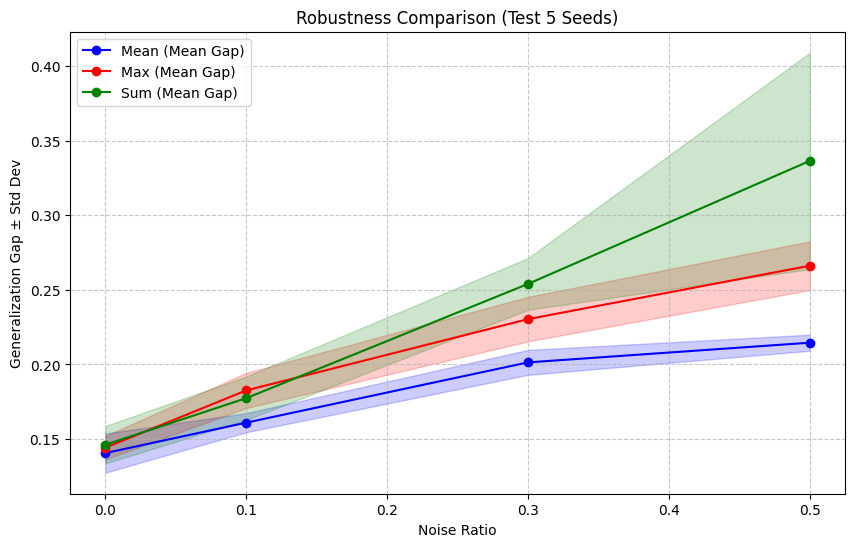

In [14]:
plt.figure(figsize=(10, 6))
colors = {'mean': 'blue', 'max': 'red', 'sum': 'green'}

for aggr in ['mean', 'max', 'sum']:
    means = np.array(results[aggr]['means'])
    stds = np.array(results[aggr]['stds'])
    plt.plot(noise_levels, means, label=f'{aggr.capitalize()} (Mean Gap)', color=colors[aggr], marker='o')
    plt.fill_between(noise_levels, means - stds, means + stds, color=colors[aggr], alpha=0.2)

plt.title('Robustness Comparison (Test 5 Seeds)')
plt.xlabel('Noise Ratio')
plt.ylabel('Generalization Gap ± Std Dev')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [15]:
# scipy t-test

from scipy.stats import ttest_ind_from_stats

test_mean_sum = ttest_ind_from_stats(results['sum']['means'], results['sum']['stds'], 5, results['mean']['means'], results['mean']['stds'], 5)

test_mean_max = ttest_ind_from_stats(results['max']['means'], results['max']['stds'], 5, results['mean']['means'], results['mean']['stds'], 5)

test_sum_max = ttest_ind_from_stats(results['max']['means'], results['max']['stds'], 5, results['sum']['means'], results['sum']['stds'], 5)

print(test_sum_max)
print(test_mean_max)
print(test_mean_sum)

Ttest_indResult(statistic=array([-0.30294686,  0.62003258, -2.3056728 , -2.11451051]), pvalue=array([0.76965835, 0.5524836 , 0.05002587, 0.06739857]))
Ttest_indResult(statistic=array([0.52533756, 3.59361702, 3.7891181 , 6.7109266 ]), pvalue=array([6.13593277e-01, 7.04734349e-03, 5.31851216e-03, 1.50996457e-04]))
Ttest_indResult(statistic=array([0.6901494 , 2.3035162 , 6.10934432, 3.74842514]), pvalue=array([5.09622558e-01, 5.01945651e-02, 2.86507232e-04, 5.63692595e-03]))


In [11]:
import torch_geometric.transforms as T
import numpy as np

transform = T.RandomNodeSplit(num_train_per_class=20, num_val=500, num_test=1000)

def calculate_absolute_test_acc(aggr_type, noise_level, num_seeds=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    test_accs = []

    for seed in range(num_seeds):
        torch.manual_seed(seed)
        data_split = transform(data).to(device)
        noisy_edge_index = add_noise(data.edge_index, noise_level)
        model = GNN(hidden_channels=16, aggr=aggr_type).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0)

        for _ in range(200):
            model.train()
            optimizer.zero_grad()
            out = model(data.x.to(device), noisy_edge_index)
            loss = F.cross_entropy(out[data_split.train_mask], data.y[data_split.train_mask].to(device))
            loss.backward()
            optimizer.step()

        model.eval()
        logits = model(data.x.to(device), noisy_edge_index)
        prediction = logits.argmax(dim=1)
        test_acc = (prediction[data_split.test_mask] == data.y[data_split.test_mask].to(device)).sum().item() / data_split.test_mask.sum().item()
        test_accs.append(test_acc)

    return np.mean(test_accs), np.std(test_accs)

abs_results = {aggr: {'means': [], 'stds': []} for aggr in ['mean', 'max', 'sum']}

for aggr in ['mean', 'max', 'sum']:
    print(f"Calculating Absolute Test Acc for {aggr}...")
    for level in noise_levels:
        m, s = calculate_absolute_test_acc(aggr, level)
        abs_results[aggr]['means'].append(m)
        abs_results[aggr]['stds'].append(s)

Calculating Absolute Test Acc for mean...
Calculating Absolute Test Acc for max...
Calculating Absolute Test Acc for sum...


--- LaTeX Table Code ---
\begin{tabular}{llll}
\toprule
Noise % & Mean & Max & Sum \\
\midrule
0% & 0.859 ± 0.013 & 0.856 ± 0.008 & 0.854 ± 0.012 \\
10% & 0.839 ± 0.006 & 0.817 ± 0.012 & 0.823 ± 0.015 \\
30% & 0.799 ± 0.008 & 0.770 ± 0.015 & 0.746 ± 0.017 \\
50% & 0.785 ± 0.005 & 0.734 ± 0.016 & 0.636 ± 0.126 \\
\bottomrule
\end{tabular}



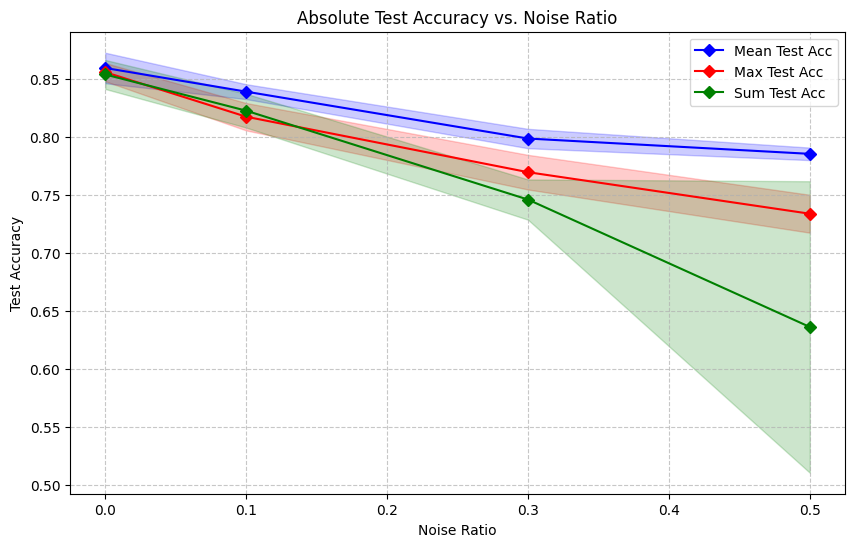

In [14]:
import pandas as pd

rows = []
colors = {'mean': 'blue', 'max': 'red', 'sum': 'green'}
for i, level in enumerate(noise_levels):
    row = {'Noise %': f"{level*100:.0f}%"}
    for aggr in ['mean', 'max', 'sum']:
        val = f"{abs_results[aggr]['means'][i]:.3f} ± {abs_results[aggr]['stds'][i]:.3f}"
        row[aggr.capitalize()] = val
    rows.append(row)

df_table = pd.DataFrame(rows)
print(df_table.to_latex(index=False))

plt.figure(figsize=(10, 6))
for aggr in ['mean', 'max', 'sum']:
    means = np.array(abs_results[aggr]['means'])
    stds = np.array(abs_results[aggr]['stds'])
    plt.plot(noise_levels, means, label=f'{aggr.capitalize()} Test Acc', color=colors[aggr], marker='D')
    plt.fill_between(noise_levels, means - stds, means + stds, color=colors[aggr], alpha=0.2)

plt.title('Absolute Test Accuracy vs. Noise Ratio')
plt.xlabel('Noise Ratio')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()